> ### Note on Labs and Assignments:
>
> 🔧 Look for the **wrench emoji** 🔧 — it highlights where you're expected to take action!
>
> These sections are graded and are not optional.
>

# IS 4487 Lab 5: EDA

## Outline

- Univariate analysis (distributions, histograms, counts)
- Bivariate analysis (correlations, scatterplots, group comparisons)
- Reflections and insights

This lab uses the same dataset from **Lab 4**. You will see some overlap in the initial tasks as the data is cleaned.  

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Labs/lab_05_eda.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## SF Rentals - Business Context

This dataset represents actual rental listings in the San Francisco housing market, which is known for its high prices, competitive demand, and neighborhood-level variation. In a business context, this type of data could be used by real estate companies, rental platforms, investors, or property managers to better understand pricing trends and market dynamics. The variables provide multiple angles for analysis: pricing (price) can be compared with property features like size (sqft), bedrooms and bathrooms, and whether the listing is a full apartment or just a room; location data (nhood, lat, lon) allows for geographic analysis of rent differences across neighborhoods; and time variables (date, year) help track how the market changes over time. Text fields like title and descr can even be analyzed to understand how listings are marketed. By exploring this dataset, analysts can answer questions such as what factors drive higher rent, which neighborhoods are most expensive, or how prices have changed over time. This kind of analysis is valuable for setting competitive prices, identifying investment opportunities, and helping renters or companies make informed housing decisions.

Note that many of the columns (variables) will be empty.  This is an unfortunate reality in the real world!

Some rentals are apartments, others are for homes, and there may be some other random properties for rent.  Each row represents one rental listing.

**Source:** Pennington, Kate (2018). Bay Area Craigslist Rental Housing Posts, 2000-2018. Retrieved from [Github](https://github.com/katepennington/historic_bay_area_craigslist_housing_posts/blob/master/clean_2000_2018.csv.zip).

## Data Dictionary

| Variable       | Type       | Description |
|----------------|------------|-------------|
| `post_id`      | Categorical| Unique listing ID |
| `date`         | Numeric    | Listing date (numeric format) |
| `year`         | Integer    | Year of listing |
| `nhood`        | Categorical| Neighborhood |
| `city`         | Categorical| City |
| `county`       | Categorical| County |
| `price`        | Numeric    | Listing price (USD) |
| `beds`         | Numeric    | Number of bedrooms |
| `baths`        | Numeric    | Number of bathrooms |
| `sqft`         | Numeric    | Square footage |
| `room_in_apt`  | Binary     | Indicates whether the rental listing is for an entire apartment (0) or a single room within an apartment (1)|
| `address`      | Categorical| Street address |
| `lat`          | Numeric    | Latitude |
| `lon`          | Numeric    | Longitude |
| `title`        | Text       | Listing title |
| `descr`        | Text       | Listing description |
| `details`      | Text       | Additional details |


## 1. Importing the Data

### Instructions:
- Import the `pandas` library for dataframes.  Then `Matplotlib` and `Seaborn` for data visualization.
- Import data from the rent.csv into a dataframe from the tidytuesday link.
- Use `.info()` and `.head()` to inspect the structure and preview the data.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
url = 'https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/refs/heads/main/DataSets/rent.csv'
df = pd.read_csv(url)

/tmp/ipykernel_4254/4027342650.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(url)


In [4]:
# Get summary info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200810 entries, 0 to 200809
Data columns (total 17 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   post_id      200810 non-null  object 
 1   date         200797 non-null  object 
 2   year         200796 non-null  float64
 3   nhood        200796 non-null  object 
 4   city         200796 non-null  object 
 5   county       199402 non-null  object 
 6   price        200796 non-null  float64
 7   beds         194188 non-null  float64
 8   baths        42675 non-null   float64
 9   sqft         64679 non-null   float64
 10  room_in_apt  200796 non-null  float64
 11  address      3908 non-null    object 
 12  lat          7651 non-null    float64
 13  lon          4312 non-null    float64
 14  title        198279 non-null  object 
 15  descr        3254 non-null    object 
 16  details      8015 non-null    object 
dtypes: float64(8), object(9)
memory usage: 26.0+ MB


In [5]:
# Preview the first rows
df.head()

,post_id,date,year,nhood,city,county,price,beds,baths,sqft,room_in_apt,address,lat,lon,title,descr,details
0,pre2013_134138,20050111,2005.0,alameda,alameda,alameda,1250.0,2.0,2.0,NaN,0.0,NaN,NaN,NaN,$1250 / 2br - 2BR/2BA 1145 ALAMEDA DE LAS PU...,NaN,NaN
1,pre2013_135669,20050126,2005.0,alameda,alameda,alameda,1295.0,2.0,NaN,NaN,0.0,NaN,NaN,NaN,$1295 / 2br - Walk the Beach! 1 FREE MONTH + $...,NaN,NaN
2,pre2013_127127,20041017,2004.0,alameda,alameda,alameda,1100.0,2.0,NaN,NaN,0.0,NaN,NaN,NaN,$1100 / 2br - cottage,NaN,NaN
3,pre2013_68671,20120601,2012.0,alameda,alameda,alameda,1425.0,1.0,NaN,735.0,0.0,NaN,NaN,NaN,$1425 / 1br - 735ft² - BEST LOCATION SOUTHSHOR...,NaN,NaN
4,pre2013_127580,20041021,2004.0,alameda,alameda,alameda,890.0,1.0,NaN,NaN,0.0,NaN,NaN,NaN,"$890 / 1br - Classy ""Painted Lady"" VICTORIAN -...",NaN,NaN


## 2. Inspecting Data Quality

### Instructions:
- Check for outliers or invalid data in key numeric variables like `price`, `sqft`, `beds`, or `baths`.  The concept of outliers will be covered more in week 6.  This week we will just look for outliers, but we won't take steps to remove them.     

In [6]:
# Basic summary statistics
df[['price', 'beds', 'baths', 'sqft']].describe()

,price,beds,baths,sqft
count,200796.000000,194188.000000,42675.000000,64679.000000
mean,2135.362746,1.889025,1.679086,1201.827688
std,1427.747903,1.079138,0.690509,5000.217864
min,220.000000,0.000000,1.000000,80.000000
25%,1295.000000,1.000000,1.000000,750.000000
50%,1800.000000,2.000000,2.000000,1000.000000
75%,2505.000000,3.000000,2.000000,1360.000000
max,40000.000000,12.000000,8.000000,900000.000000


### Reflection:
- 2.1 Do any numeric variables contain extreme or unusual values?
- 2.2 Should those outlier values be removed?  Or are they valid rental properties?

### ✍️ Your Response: 🔧
2.1 Yes, there are numeric variables containing extreme or unusual values, like the price and square footage values are much higher than the other rental listings.

2.2  The outliers shouldn't be removed just yet because it could be valid rentla properties. The values should be analyzed first to make sure there's no errors.

## 3. Univariate Analysis

Explore individual variables to understand their distributions and frequency.

### Tasks:
- Plot histograms for numeric variables (`price`, `sqft`)
- Plot countplots for categorical variables (`beds`, `nhood`)


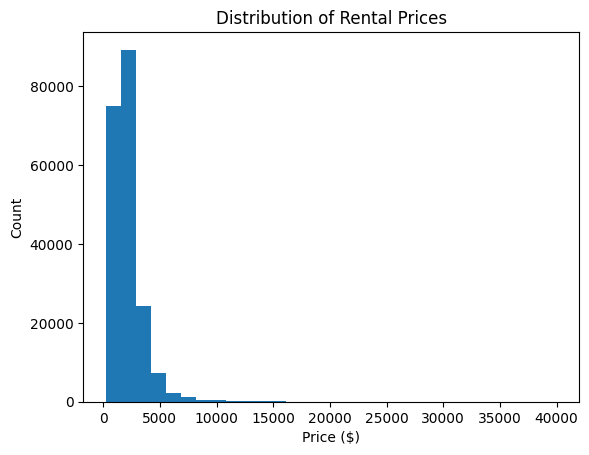

In [7]:
# Histogram: Price
plt.hist(df['price'], bins=30)
plt.title("Distribution of Rental Prices")
plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.show()

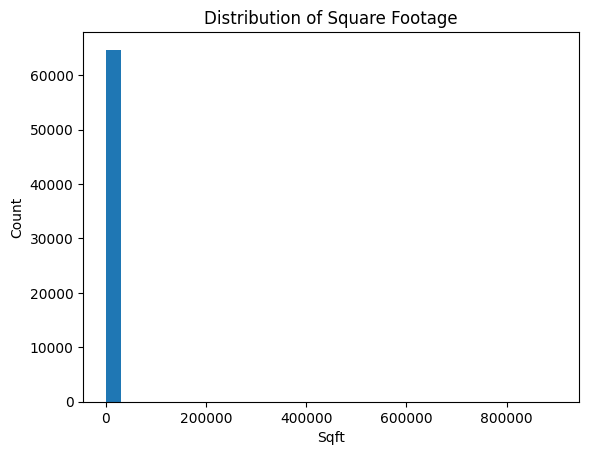

In [8]:
# Histogram: Square Footage
plt.hist(df['sqft'].dropna(), bins=30)
plt.title("Distribution of Square Footage")
plt.xlabel("Sqft")
plt.ylabel("Count")
plt.show()


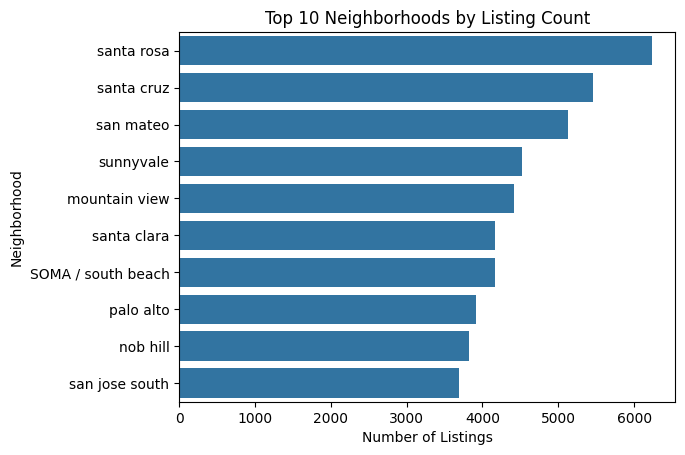

In [9]:
# Bar plot of top 10 neighborhoods by number of listings
top_nhoods = df['nhood'].value_counts().head(10)

sns.barplot(x=top_nhoods.values, y=top_nhoods.index)
plt.title("Top 10 Neighborhoods by Listing Count")
plt.xlabel("Number of Listings")
plt.ylabel("Neighborhood")
plt.show()

### 🔧 Do the following – Part 3

1. Create two new visualizations using different variables than the ones already shown above.

>Suggestions:
- A **histogram** of the `baths` variable
- A **bar chart** showing the **average square footage by number of bathrooms**

> Be sure to label your axes and include a title for each chart.

### Reflection:

After creating each of the visuals, write 1–2 sentences explaining what you notice in each.


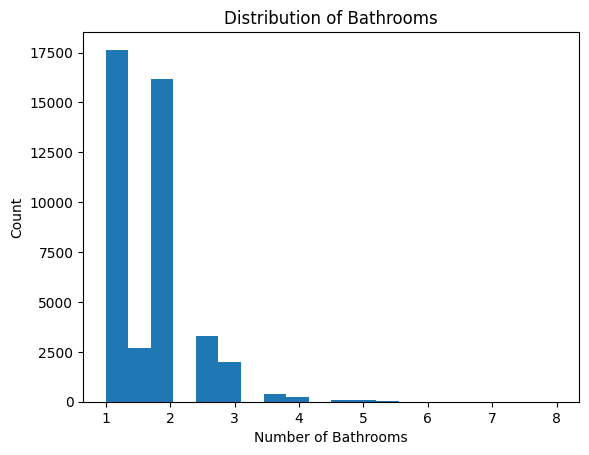

In [10]:
# Histogram of bathrooms
plt.hist(df['baths'].dropna(), bins=20)

plt.title("Distribution of Bathrooms")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Count")

plt.show()

### ✍️ Visual 1 Response: 🔧
1. From the visual, I can see that the distribution of bathrooms are kept at a smaller number, around 1-2 bathrooms, and listings with more bathrooms are less common.

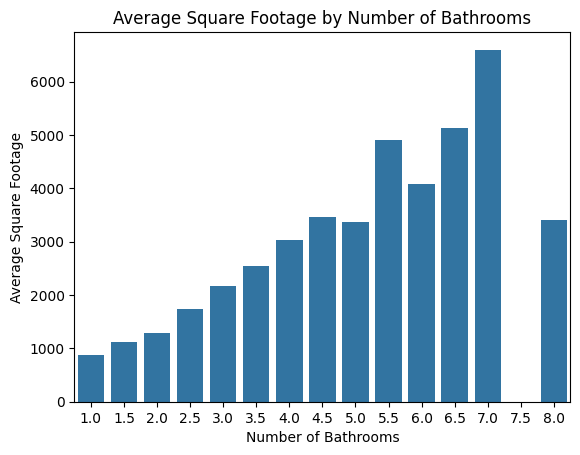

In [11]:
# Average square footage by number of bathrooms
avg_sqft_baths = df.groupby('baths')['sqft'].mean().sort_index()

sns.barplot(x=avg_sqft_baths.index, y=avg_sqft_baths.values)

plt.title("Average Square Footage by Number of Bathrooms")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Average Square Footage")

plt.show()

### ✍️ Visual 2 Response: 🔧
1. From this visual, I see that generally, the higher the average square footage, the more bathrooms the listing will have. It might not fully increase for every average square footage though.  

## 4. Bivariate Analysis

Explore relationships between two variables to understand how features like square footage or bedrooms influence price.


In [12]:
# Correlation matrix
corr_matrix = df[['price', 'beds', 'baths', 'sqft']].corr()
corr_matrix


,price,beds,baths,sqft
price,1.000000,0.450096,0.433553,0.074310
beds,0.450096,1.000000,0.651835,0.707235
baths,0.433553,0.651835,1.000000,0.645372
sqft,0.074310,0.707235,0.645372,1.000000


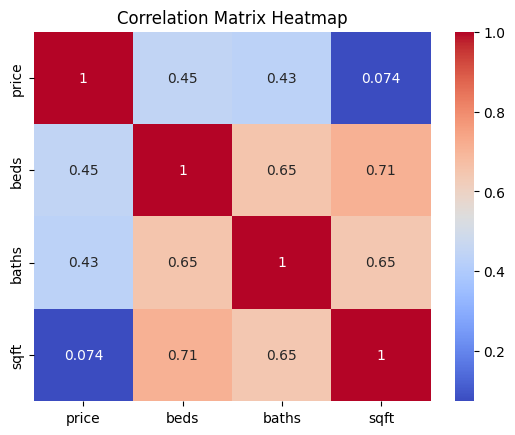

In [13]:
# Heatmap of correlation matrix
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix Heatmap")
plt.show()

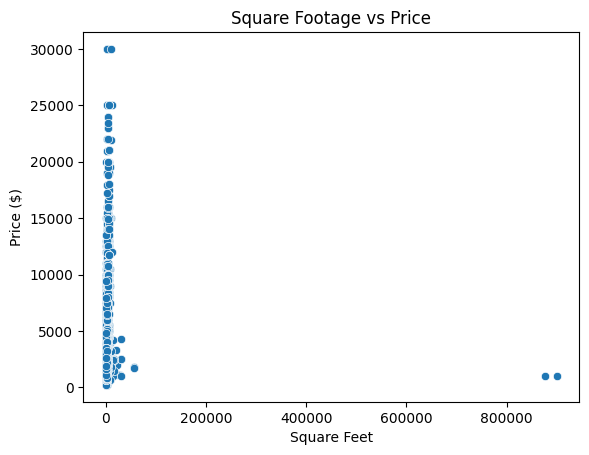

In [14]:
# Scatterplot: Square Footage vs Price
sns.scatterplot(x='sqft', y='price', data=df)
plt.title("Square Footage vs Price")
plt.xlabel("Square Feet")
plt.ylabel("Price ($)")
plt.show()

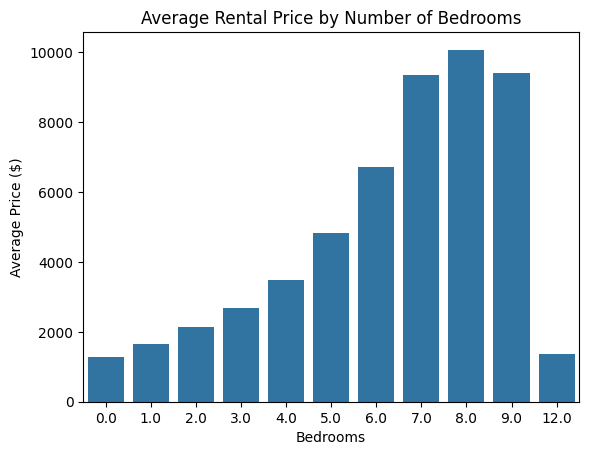

In [15]:
# Average price by number of bedrooms
avg_price_beds = df.groupby('beds')['price'].mean().sort_index()
sns.barplot(x=avg_price_beds.index, y=avg_price_beds.values)
plt.title("Average Rental Price by Number of Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Average Price ($)")
plt.show()

### 🔧 Do the following – Part 4

- 4.1 Create a scatterplot of `baths` vs `price`.  
- 4.2 Group by `year` and plot the average price over time.

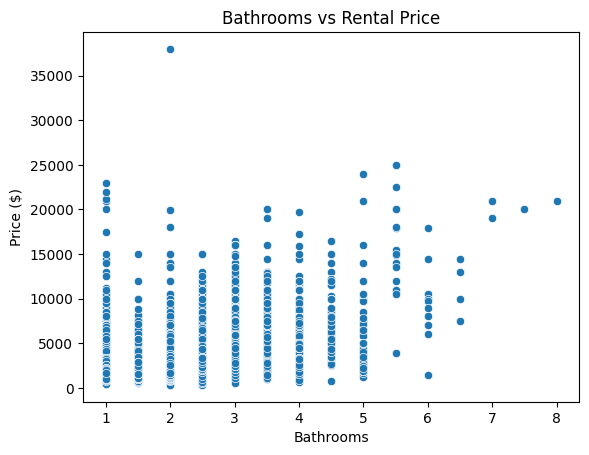

In [16]:
sns.scatterplot(x='baths', y='price', data=df)

plt.title("Bathrooms vs Rental Price")
plt.xlabel("Bathrooms")
plt.ylabel("Price ($)")

plt.show()

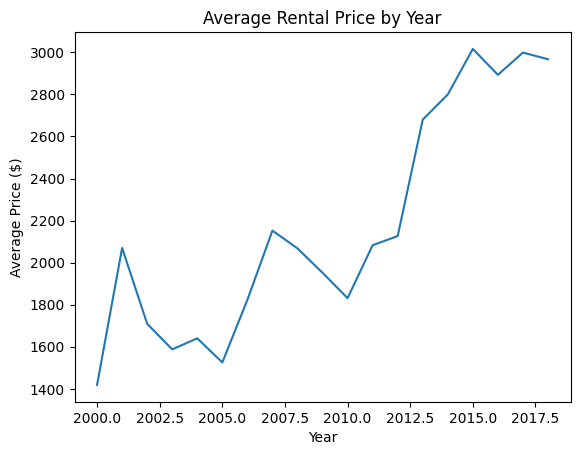

In [17]:
avg_price_year = df.groupby('year')['price'].mean().sort_index()

plt.plot(avg_price_year.index, avg_price_year.values)

plt.title("Average Rental Price by Year")
plt.xlabel("Year")
plt.ylabel("Average Price ($)")

plt.show()

### Reflection:
4.1 What trends or outliers do you see?

### ✍️ Your Response: 🔧
4.1 A trend that I see is that on the scatterplot, the rental prices increase as the number of bathrooms increases. But I also see that there are some unusual values which could be outliers. So, I see a lot of variation between the rental price and the number of bathrooms.

## 🔧  Part 5: Reflection

Answer the following questions in the markdown cell below (no more than a few sentences per question required)

- 5.1 Which variables are most strongly correlated with rental price?
- 5.2 Are there patterns in how size (sqft) or number of bedrooms affects price?
- 5.3 Which neighborhoods or years show the highest prices?
- 5.4 What other visualizations or groupings might improve this analysis?

Use this section to summarize insights from both Labs 4 and 5.

### ✍️ Your Response: 🔧
5.1  The variables that are most strongly correlated with rental price are mainly the square footage or the number of bedrooms/bathrooms. However, the strength of those sections can vary.

5.2 There's actually a strong positive relationship between the rental price and the size (sqft) or number of bedrooms. The graphs showed that the larger the property was, the higher the rental prices were. Neighborhood and property type also affected the rental prices though.

5.3 The neighborhoods with the highest prices (from the codes I used below) were Iverness with the average price of 5310. The year with the highest price was 2015 with a price of 3016.05.

5.4 Some other visualizations or groupings that might improve this analysis would be adding other graphs like a boxplot to help identify any possible outliers or unusual values. We could also use geograph visualizations depending on the area and rental prices.


In [18]:
avg_price_nhood = df.groupby('nhood')['price'].mean().sort_values(ascending=False).head(10)

print(avg_price_nhood)

nhood
inverness                     5310.000000
atherton                      4536.010989
tiburon / belvedere           4265.346591
financial district            3958.161417
west portal / forest hills    3827.276119
saratoga                      3801.850900
kentfield / ross              3611.577855
los altos                     3605.047072
SOMA / south beach            3585.900793
pacific heights               3487.850301
Name: price, dtype: float64


In [19]:
avg_price_year = df.groupby('year')['price'].mean().sort_values(ascending=False)

print(avg_price_year)

year
2015.0    3016.057967
2017.0    2998.658354
2018.0    2967.051076
2016.0    2892.953247
2014.0    2799.560424
2013.0    2679.816015
2007.0    2152.303178
2012.0    2126.308527
2011.0    2082.872963
2001.0    2070.038095
2008.0    2067.772489
2009.0    1951.866827
2010.0    1831.296377
2006.0    1822.992589
2002.0    1709.347079
2004.0    1640.209812
2003.0    1587.705745
2005.0    1525.475233
2000.0    1418.695652
Name: price, dtype: float64


## Export Your Notebook to Submit in Canvas
- Use the instructions from Lab 1

In [20]:
!jupyter nbconvert --to html "lab_05_eda.ipynb"

[NbConvertApp] WARNING | pattern 'lab_05_eda.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execute
    